# 🏦 BFSI Fraud Detection using Support Vector Machines (SVM)

---

## Problem Statement
A digital payment system processes high-volume transactions where a small fraction may represent fraud due to **abnormal spending behavior**, **location mismatch**, or **unusual transaction patterns**.

## Business Objectives
- ✅ Detect fraudulent transactions early
- ✅ Reduce false positives in fraud detection
- ✅ Improve customer transaction safety
- ✅ Identify risk patterns in behavior

## ML Objective
Use **SVM** to classify transactions as **Fraudulent** or **Legitimate**, and evaluate kernel-based separation of complex behavioral patterns.

---

## 📦 0. Install & Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.impute import SimpleImputer

# SVM
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)

# Timing
import time

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
COLORS = {'fraud': '#e74c3c', 'legit': '#2ecc71', 'palette': 'Set2'}

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📂 1. Data Understanding

### 1.1 Load the Dataset

In [2]:
df = pd.read_csv('dataset/bfsi_fraud_risk_dataset.csv')

print(f'📊 Dataset Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

📊 Dataset Shape : 40,250 rows × 22 columns


,TransactionID,CustomerID,CustomerAge,CustomerGender,Occupation,CityTier,AccountBalance,TransactionAmount,TransactionType,MerchantCategory,...,LoginAttempts,FailedTransactions,DaysSinceLastTransaction,AvgMonthlyTransactions,CreditScore,TransactionLocation,IPRiskScore,VPNUsed,MultipleDevicesUsed,IsFraud
0,TXN_131493,CUST_98829,67,Male,Salaried,Tier-2,238725.62,972.78,UPI,Travel,...,1,1,4,43.13,719.0,Home City,1.00,No,No,No
1,TXN_126518,CUST_54311,72,Female,Self-Employed,Tier-3,327947.40,14730.80,Debit Card,Luxury,...,1,1,48,40.03,655.0,Home City,61.24,No,Yes,No
2,TXN_121417,CUST_22483,19,Female,Business,Tier-1,217429.36,27856.07,RTGS,Travel,...,1,1,37,46.92,630.0,Home City,37.70,No,No,Yes
3,TXN_127911,CUST_3593,34,Female,Government,Tier-3,178111.94,4440.02,Credit Card,Travel,...,1,0,19,25.90,775.0,Different City,40.96,No,No,No
4,TXN_112516,CUST_24544,69,Male,Retired,Tier-1,170786.19,8481.16,Wallet,Food,...,1,1,56,69.87,657.0,Different City,1.00,No,No,No


### 1.2 Dataset Structure

In [3]:
print('=== Dataset Info ===')
df.info()
print('\n=== Basic Statistics ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40250 entries, 0 to 40249
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TransactionID             40250 non-null  object 
 1   CustomerID                40250 non-null  object 
 2   CustomerAge               40250 non-null  int64  
 3   CustomerGender            40250 non-null  object 
 4   Occupation                40250 non-null  object 
 5   CityTier                  40250 non-null  object 
 6   AccountBalance            40250 non-null  float64
 7   TransactionAmount         39041 non-null  float64
 8   TransactionType           40250 non-null  object 
 9   MerchantCategory          39046 non-null  object 
 10  TransactionHour           40250 non-null  int64  
 11  DeviceType                40250 non-null  object 
 12  LoginAttempts             40250 non-null  int64  
 13  FailedTransactions        40250 non-null

,CustomerAge,AccountBalance,TransactionAmount,TransactionHour,LoginAttempts,FailedTransactions,DaysSinceLastTransaction,AvgMonthlyTransactions,CreditScore,IPRiskScore
count,40250.000000,40250.000000,39041.000000,40250.000000,40250.000000,40250.000000,40250.000000,40250.000000,39037.000000,39042.000000
mean,45.958137,152040.422016,12935.850717,11.431652,1.494733,0.802882,29.503702,35.168671,719.340523,35.418021
std,16.423498,85417.063527,17743.360126,6.915031,1.221311,0.896243,17.290152,14.897340,79.205460,19.241393
min,18.000000,5000.000000,100.000000,0.000000,0.000000,0.000000,0.000000,1.000000,408.000000,1.000000
25%,32.000000,89983.482500,3513.980000,5.000000,1.000000,0.000000,14.000000,25.000000,665.000000,21.580000
50%,46.000000,149981.610000,8459.100000,11.000000,1.000000,1.000000,30.000000,35.040000,720.000000,35.110000
75%,60.000000,209941.577500,16835.720000,17.000000,2.000000,1.000000,44.000000,45.270000,773.000000,48.480000
max,74.000000,572502.540000,472900.640000,23.000000,9.000000,6.000000,59.000000,90.470000,900.000000,100.000000


### 1.3 Feature Classification

In [4]:
# Drop ID columns — not predictive
id_cols = ['TransactionID', 'CustomerID']
target_col = 'IsFraud'

numerical_features = df.drop(columns=id_cols + [target_col]).select_dtypes(include='number').columns.tolist()
categorical_features = df.drop(columns=id_cols + [target_col]).select_dtypes(exclude='number').columns.tolist()

print(f'🔢 Numerical Features ({len(numerical_features)})  : {numerical_features}')
print(f'🔤 Categorical Features ({len(categorical_features)}): {categorical_features}')
print(f'🎯 Target Variable                : {target_col}')

🔢 Numerical Features (10)  : ['CustomerAge', 'AccountBalance', 'TransactionAmount', 'TransactionHour', 'LoginAttempts', 'FailedTransactions', 'DaysSinceLastTransaction', 'AvgMonthlyTransactions', 'CreditScore', 'IPRiskScore']
🔤 Categorical Features (9): ['CustomerGender', 'Occupation', 'CityTier', 'TransactionType', 'MerchantCategory', 'DeviceType', 'TransactionLocation', 'VPNUsed', 'MultipleDevicesUsed']
🎯 Target Variable                : IsFraud


### 1.4 Target Variable Distribution

=== Target Variable — IsFraud ===
  No   : 29,970  (74.46%)
  Yes  : 10,280  (25.54%)


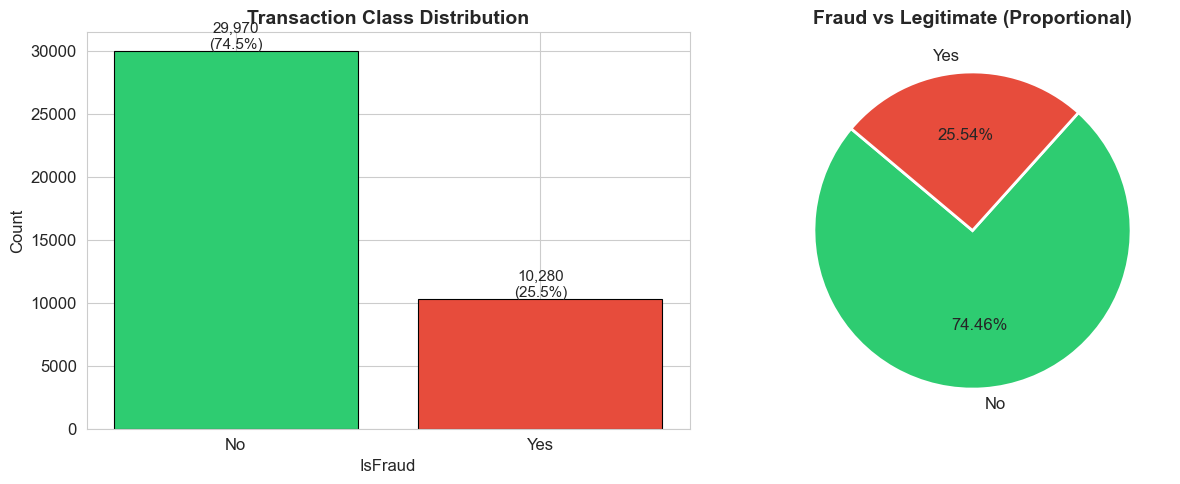


⚠️  Class Imbalance Note: Fraud transactions are ~25.5% — moderate imbalance. SVM handles this via class_weight parameter.


In [5]:
fraud_counts = df[target_col].value_counts()
fraud_pct    = df[target_col].value_counts(normalize=True) * 100

print('=== Target Variable — IsFraud ===')
for label in fraud_counts.index:
    print(f'  {label:4s} : {fraud_counts[label]:6,}  ({fraud_pct[label]:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
axes[0].bar(fraud_counts.index, fraud_counts.values,
            color=[COLORS['legit'], COLORS['fraud']], edgecolor='black', linewidth=0.8)
axes[0].set_title('Transaction Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('IsFraud'); axes[0].set_ylabel('Count')
for i, (lbl, cnt) in enumerate(fraud_counts.items()):
    axes[0].text(i, cnt + 200, f'{cnt:,}\n({fraud_pct[lbl]:.1f}%)', ha='center', fontsize=11)

# Pie chart
axes[1].pie(fraud_counts.values, labels=fraud_counts.index,
            colors=[COLORS['legit'], COLORS['fraud']],
            autopct='%1.2f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Fraud vs Legitimate (Proportional)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('\n⚠️  Class Imbalance Note: Fraud transactions are ~25.5% — moderate imbalance. SVM handles this via class_weight parameter.')

---
## 📊 2. Exploratory Data Analysis (EDA)

### 2.1 Missing Value Analysis

=== Missing Values Summary ===
                   Missing Count  Missing %
CreditScore                 1213   3.013665
TransactionAmount           1209   3.003727
IPRiskScore                 1208   3.001242
MerchantCategory            1204   2.991304


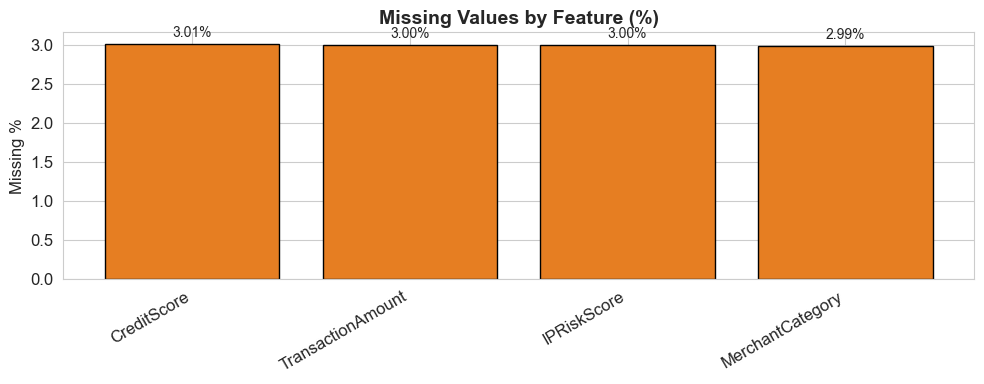

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('=== Missing Values Summary ===')
print(missing_df.to_string())

if not missing_df.empty:
    plt.figure(figsize=(10, 4))
    bars = plt.bar(missing_df.index, missing_df['Missing %'], color='#e67e22', edgecolor='black')
    plt.title('Missing Values by Feature (%)', fontsize=14, fontweight='bold')
    plt.ylabel('Missing %'); plt.xticks(rotation=30, ha='right')
    for bar, val in zip(bars, missing_df['Missing %']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.savefig('missing_values.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('✅ No missing values found!')

### 2.2 Numerical Feature Distributions

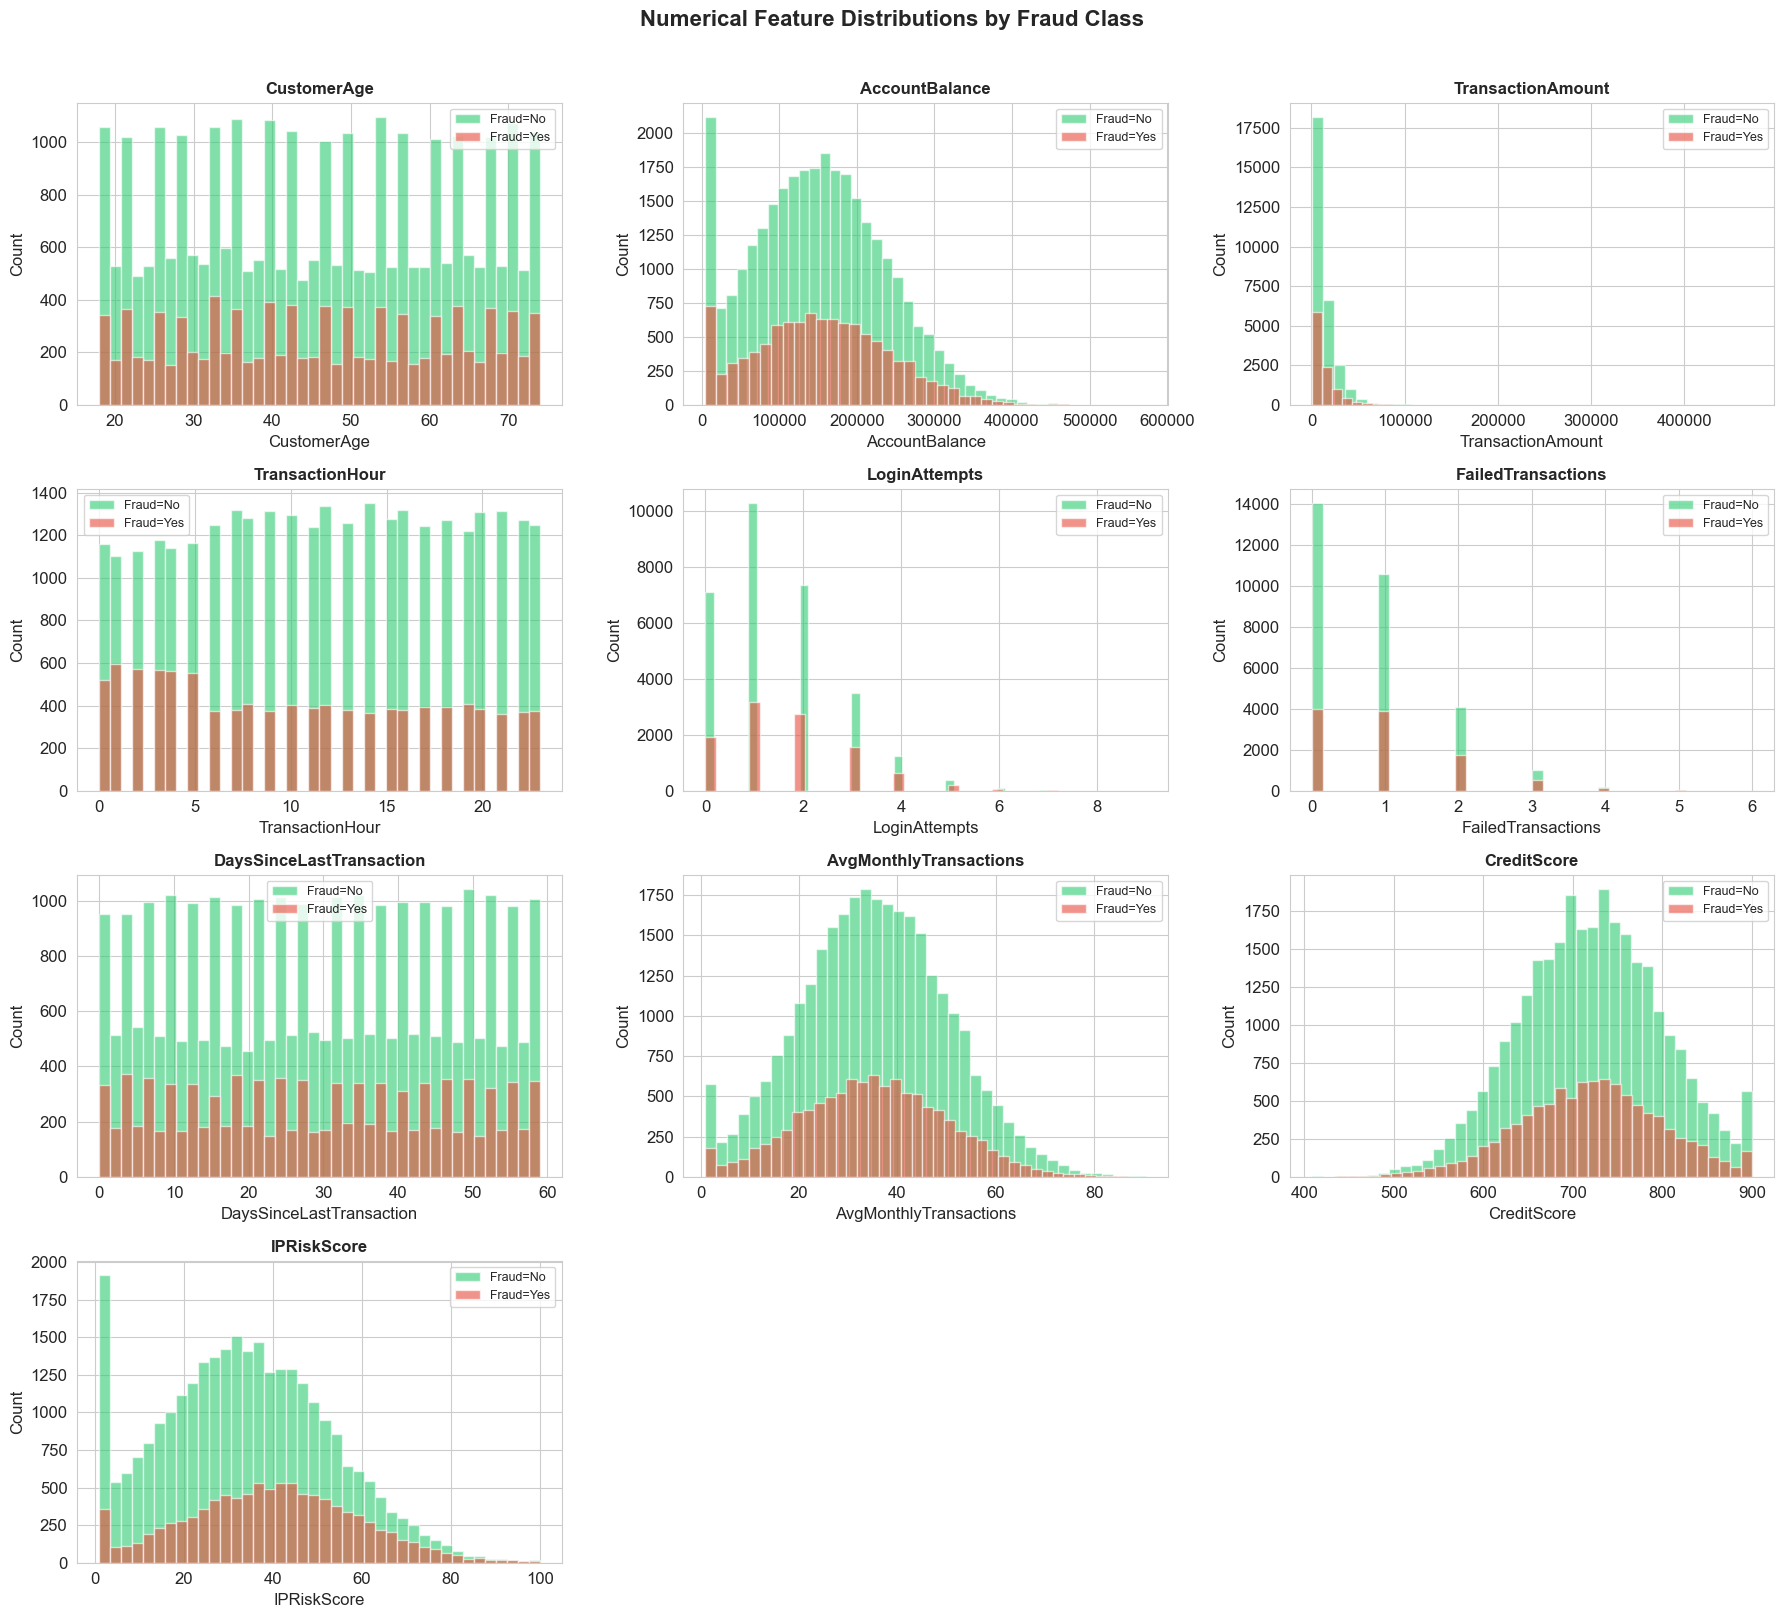

In [7]:
n_num = len(numerical_features)
ncols = 3
nrows = (n_num + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    for label, color in [('No', COLORS['legit']), ('Yes', COLORS['fraud'])]:
        subset = df[df[target_col] == label][col].dropna()
        axes[i].hist(subset, bins=40, alpha=0.6, color=color,
                     label=f'Fraud={label}', edgecolor='white')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col); axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Fraud Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.3 Categorical Feature Analysis

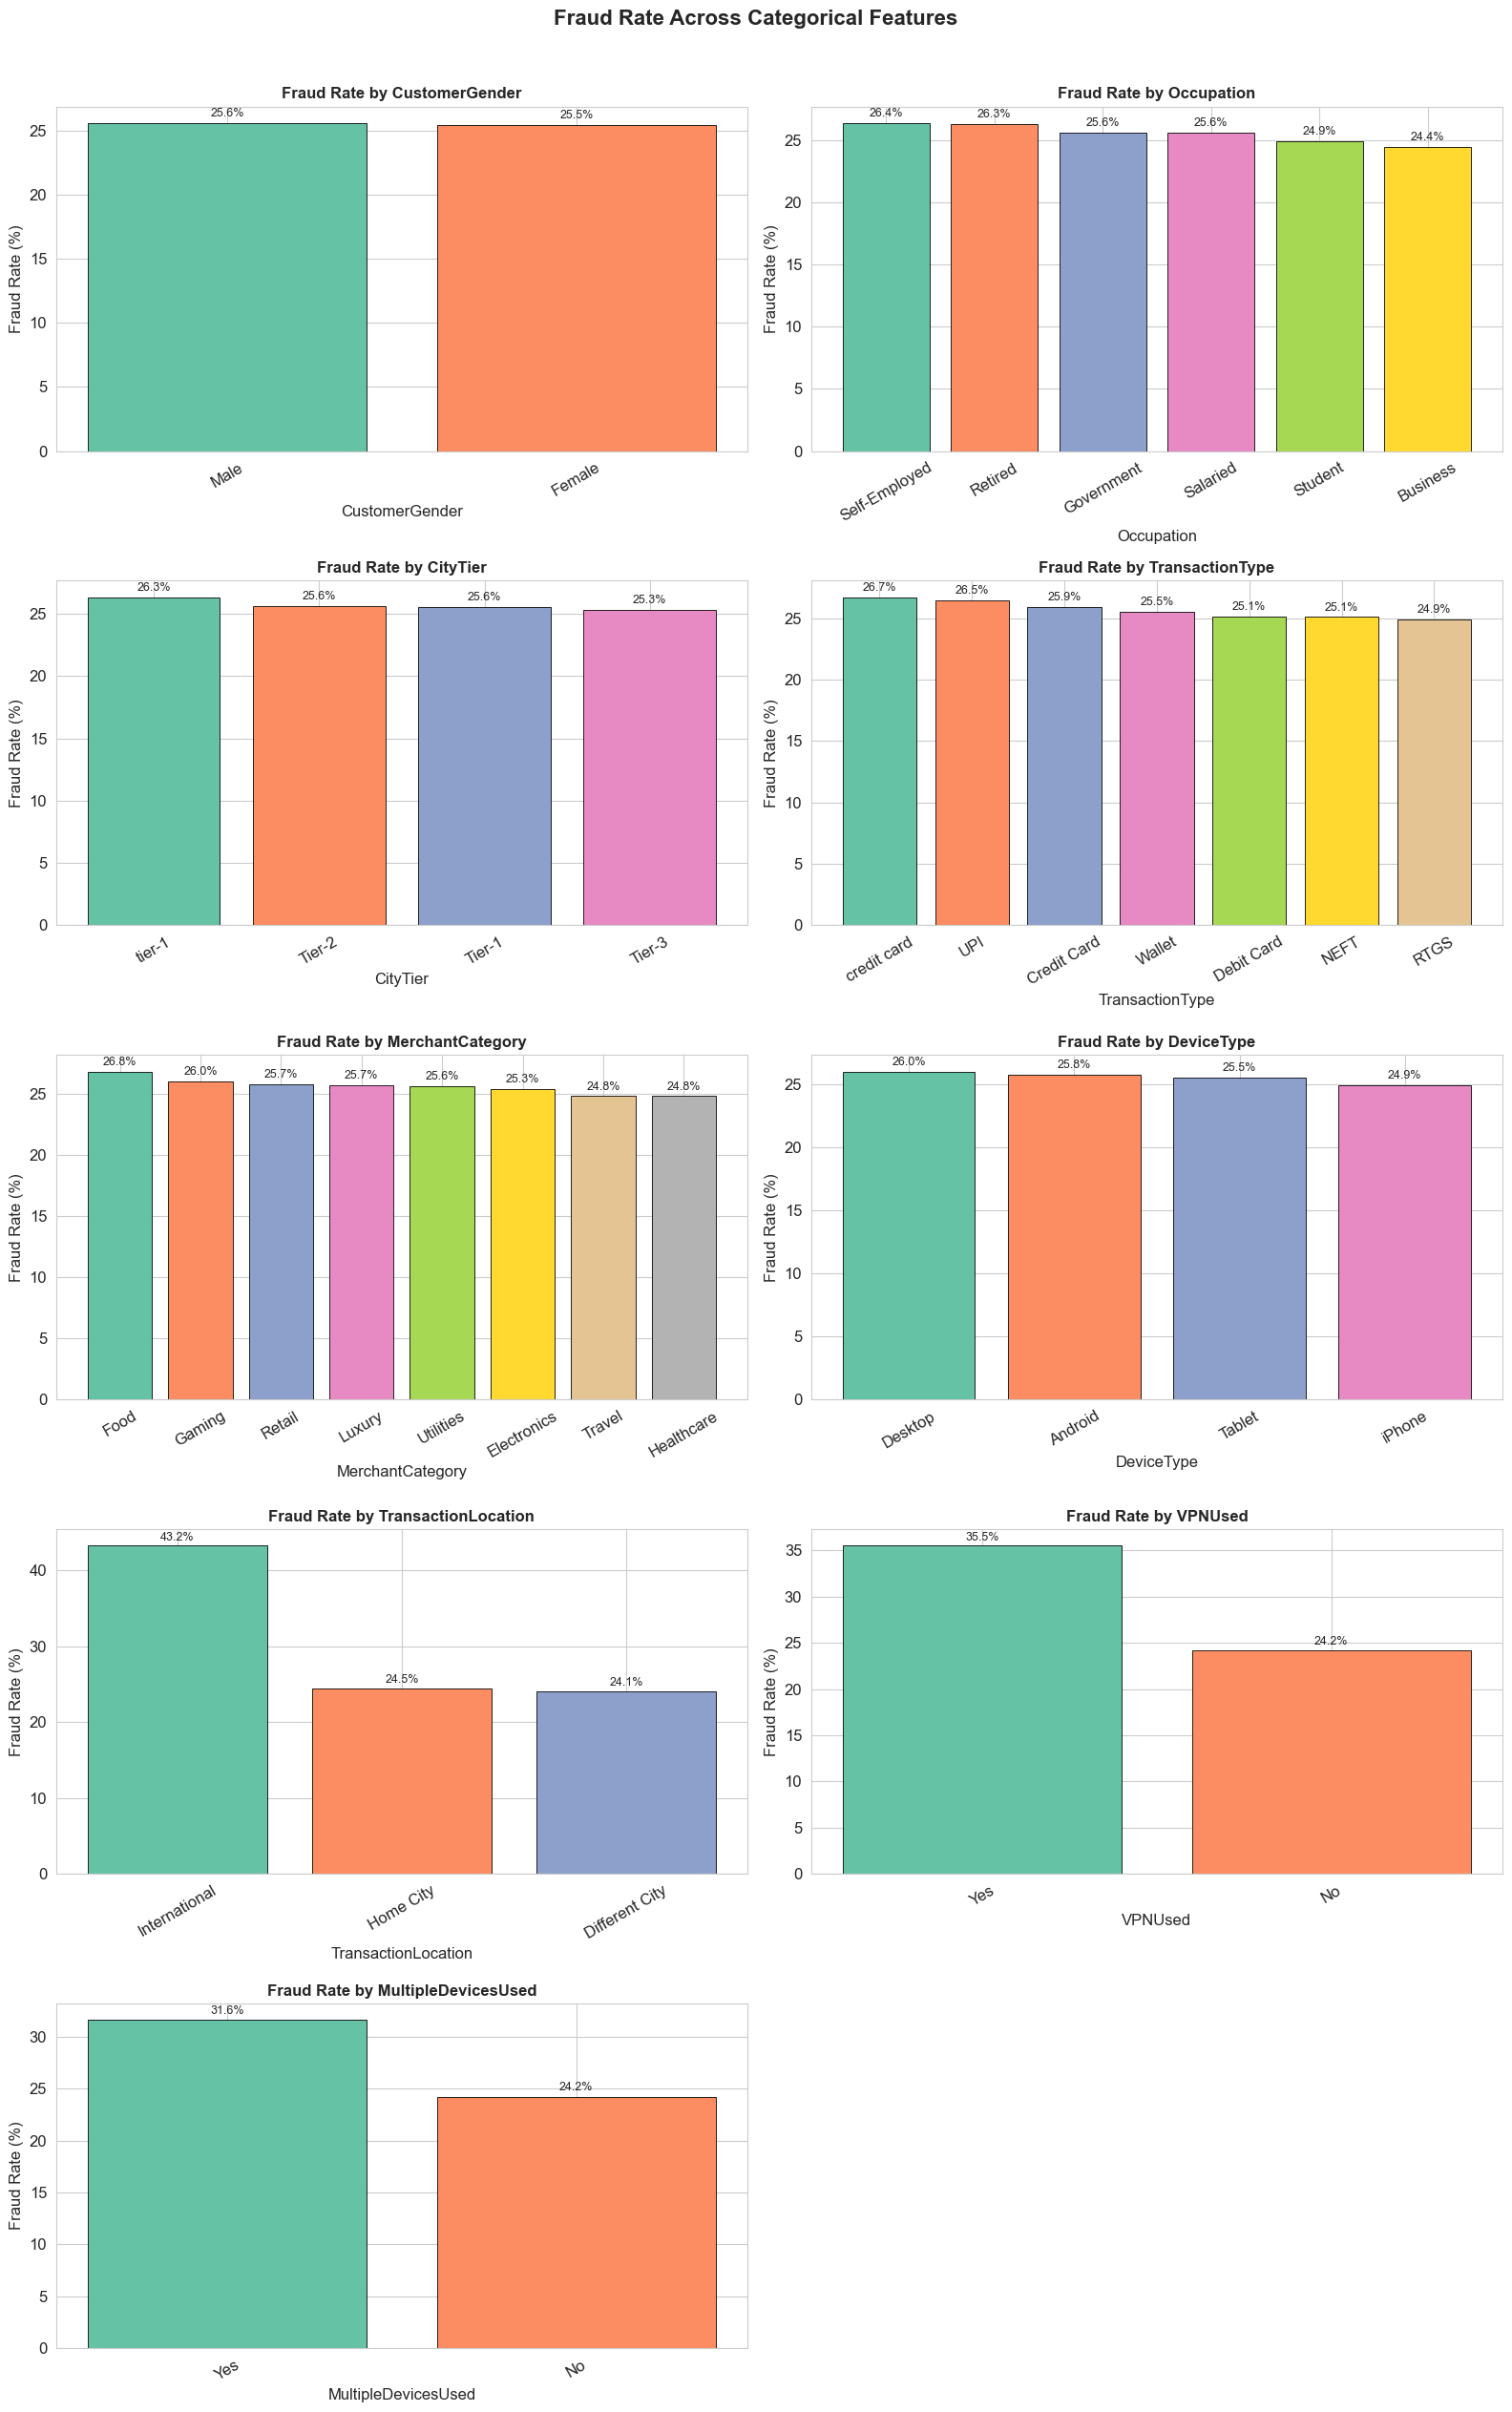

In [8]:
ncols = 2
nrows = (len(categorical_features) + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    fraud_rate = df.groupby(col)[target_col].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    fraud_rate.columns = [col, 'FraudRate']
    fraud_rate = fraud_rate.sort_values('FraudRate', ascending=False)

    bars = axes[i].bar(fraud_rate[col], fraud_rate['FraudRate'],
                       color=sns.color_palette(COLORS['palette'], len(fraud_rate)),
                       edgecolor='black', linewidth=0.6)
    axes[i].set_title(f'Fraud Rate by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Fraud Rate (%)'); axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=30)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Fraud Rate Across Categorical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('categorical_fraud_rates.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.4 Outlier Detection (Box Plots)

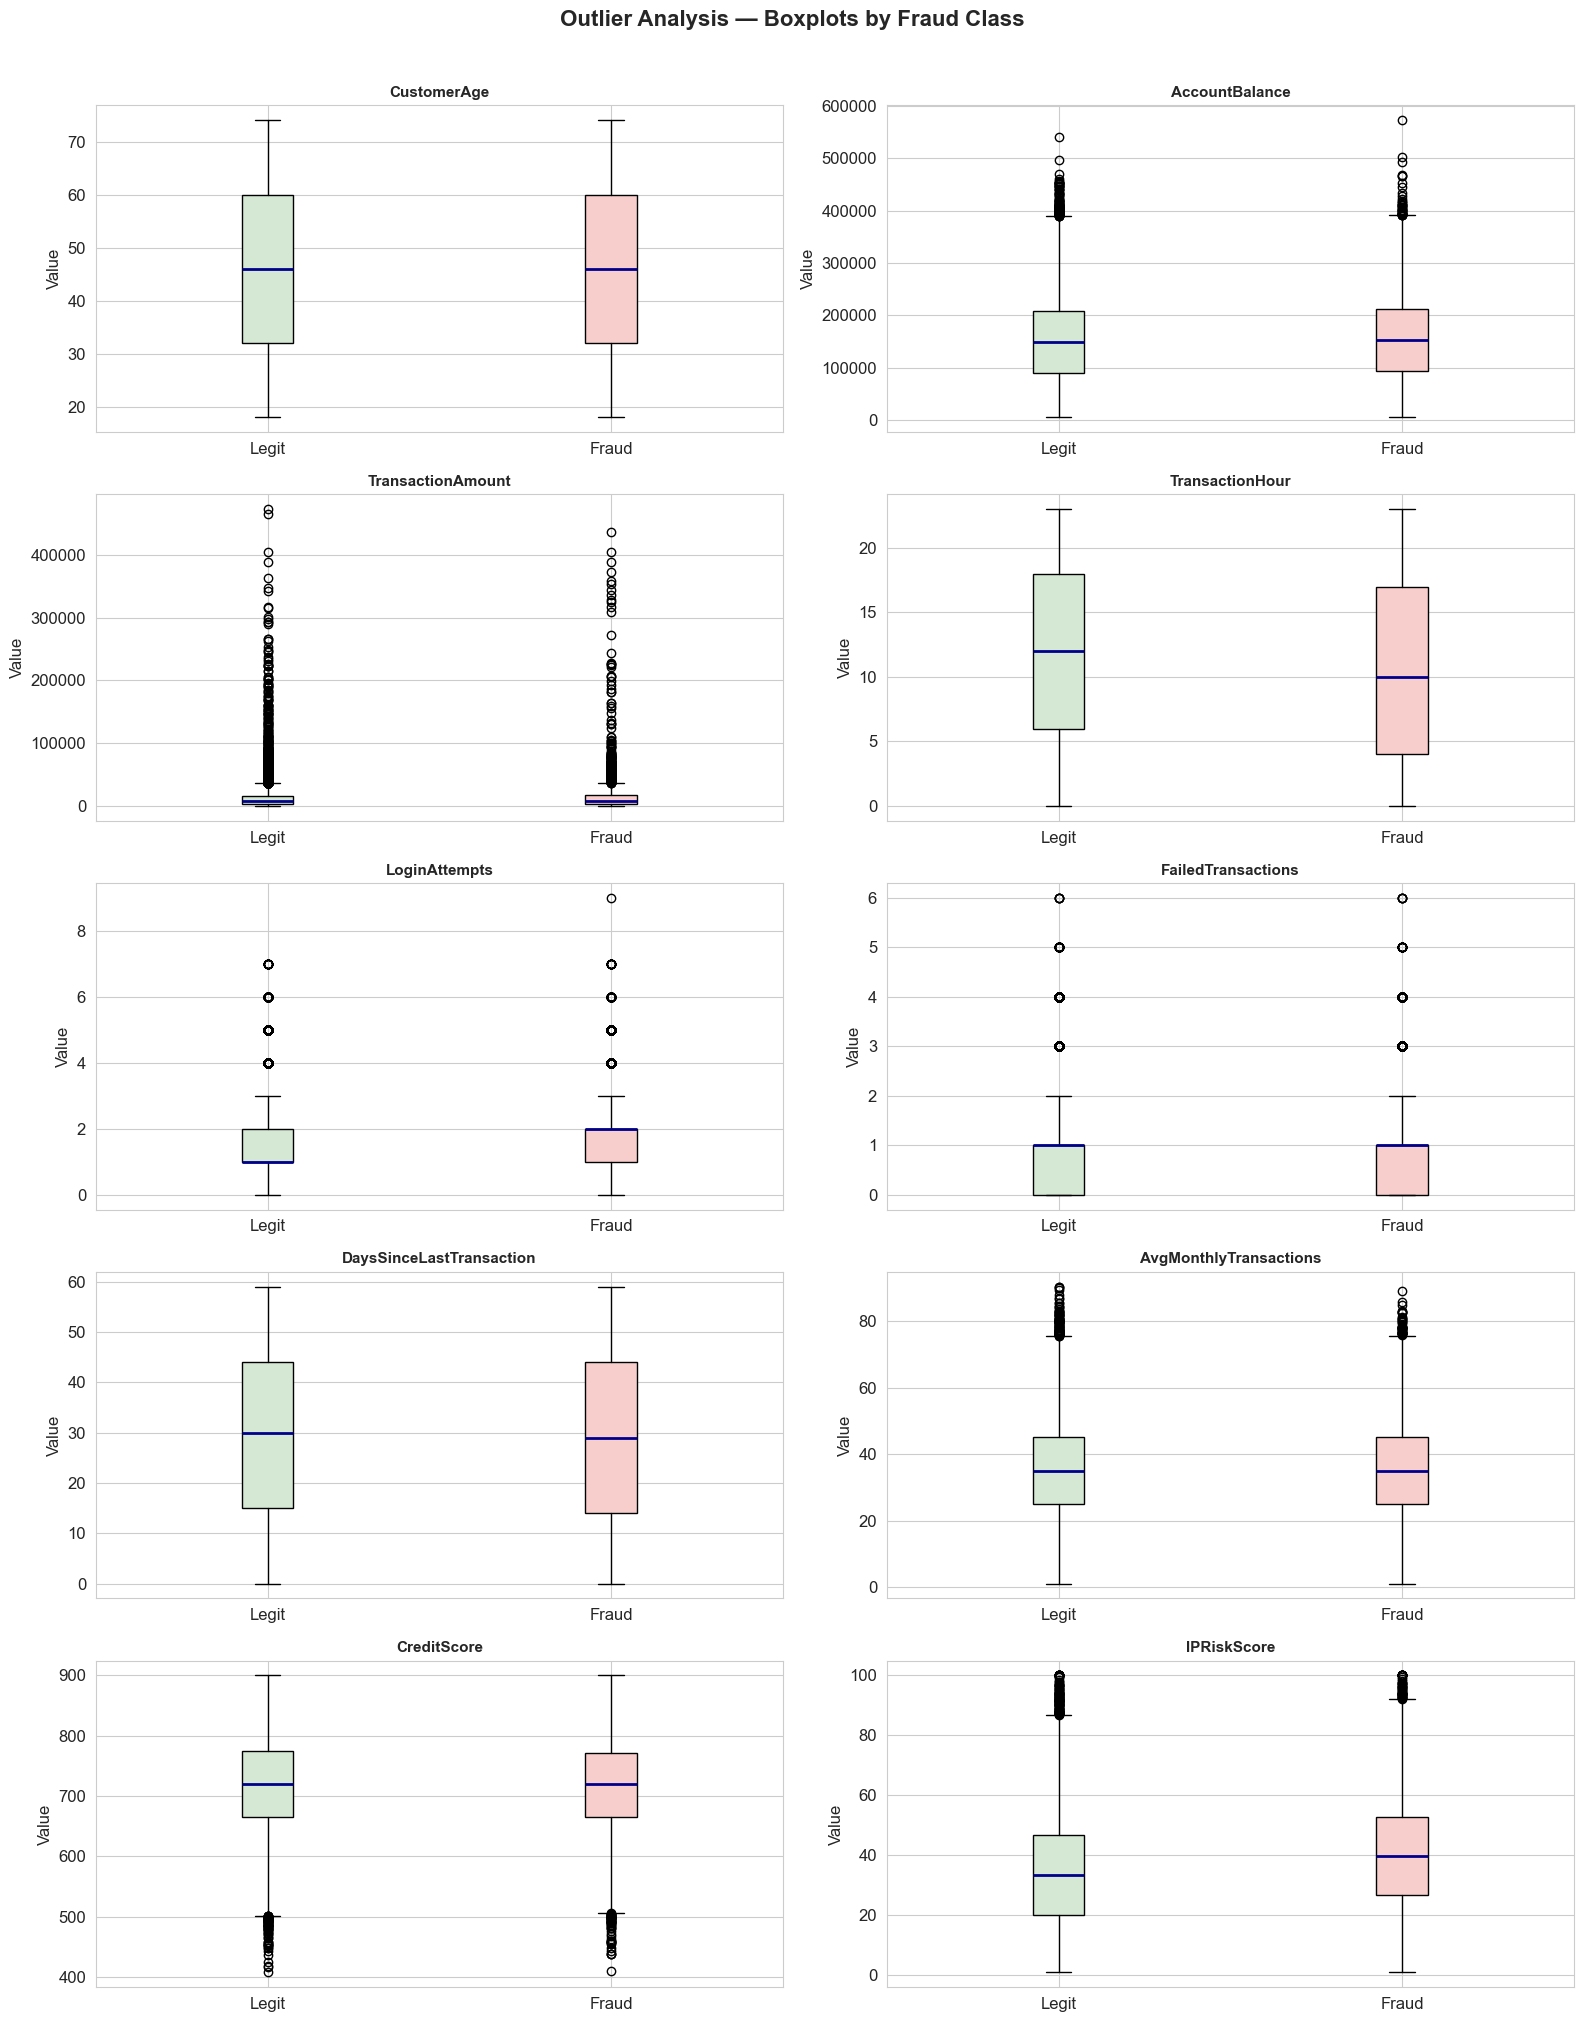

In [9]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    data_groups = [df[df[target_col] == lbl][col].dropna() for lbl in ['No', 'Yes']]
    bp = axes[i].boxplot(data_groups, labels=['Legit', 'Fraud'],
                         patch_artist=True,
                         boxprops=dict(facecolor='#d5e8d4'),
                         medianprops=dict(color='darkblue', linewidth=2))
    bp['boxes'][1].set_facecolor('#f8cecc')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Analysis — Boxplots by Fraud Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplots_outliers.png', dpi=120, bbox_inches='tight')
plt.show()

### 2.5 Correlation Heatmap

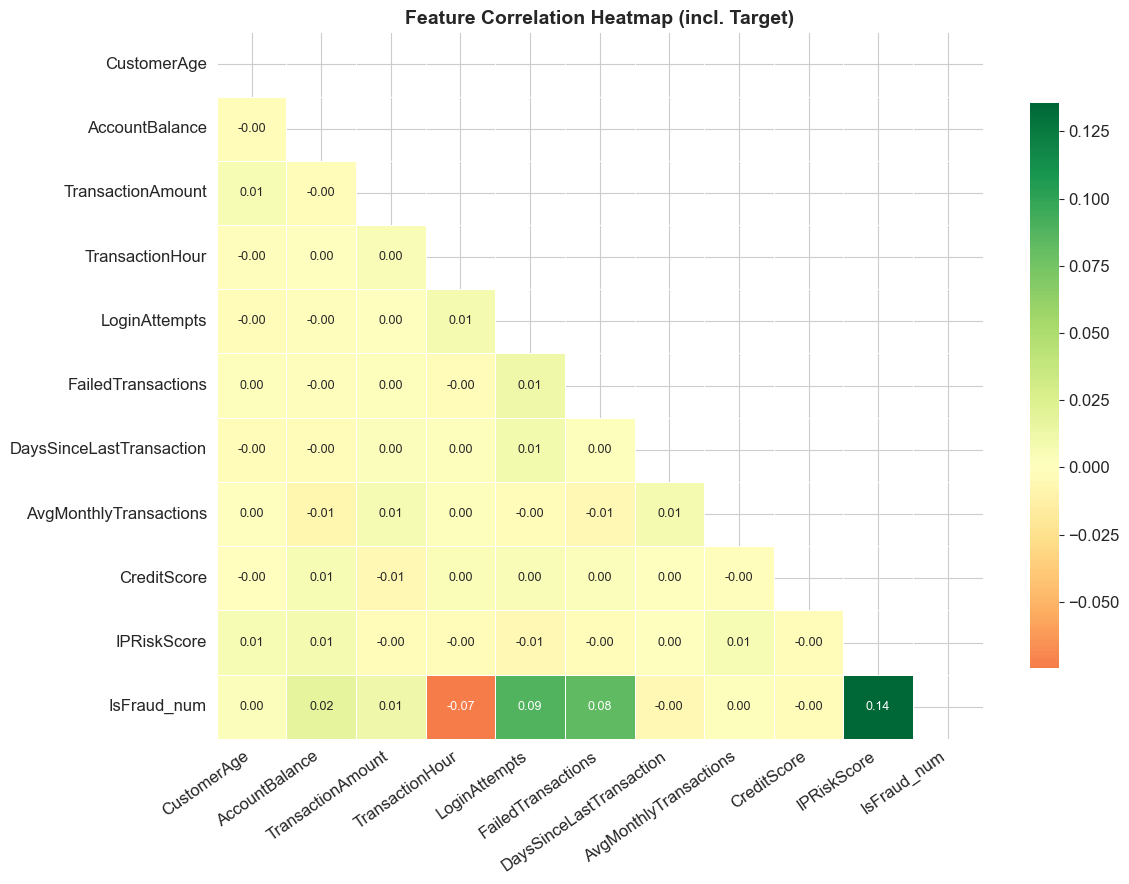


📌 Top Features Correlated with IsFraud:
IPRiskScore                 0.135526
LoginAttempts               0.087986
FailedTransactions          0.083679
TransactionHour             0.074689
AccountBalance              0.017955
TransactionAmount           0.011366
DaysSinceLastTransaction    0.004946
CustomerAge                 0.003259
CreditScore                 0.003173
AvgMonthlyTransactions      0.000966
Name: IsFraud_num, dtype: float64


In [10]:
# Binary encode target for correlation
df_corr = df.copy()
df_corr['IsFraud_num'] = (df_corr[target_col] == 'Yes').astype(int)
corr_cols = numerical_features + ['IsFraud_num']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 9}, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap (incl. Target)', fontsize=14, fontweight='bold')
plt.xticks(rotation=35, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n📌 Top Features Correlated with IsFraud:')
print(corr_matrix['IsFraud_num'].drop('IsFraud_num').abs().sort_values(ascending=False))

### 2.6 Transaction Patterns — Time & Amount

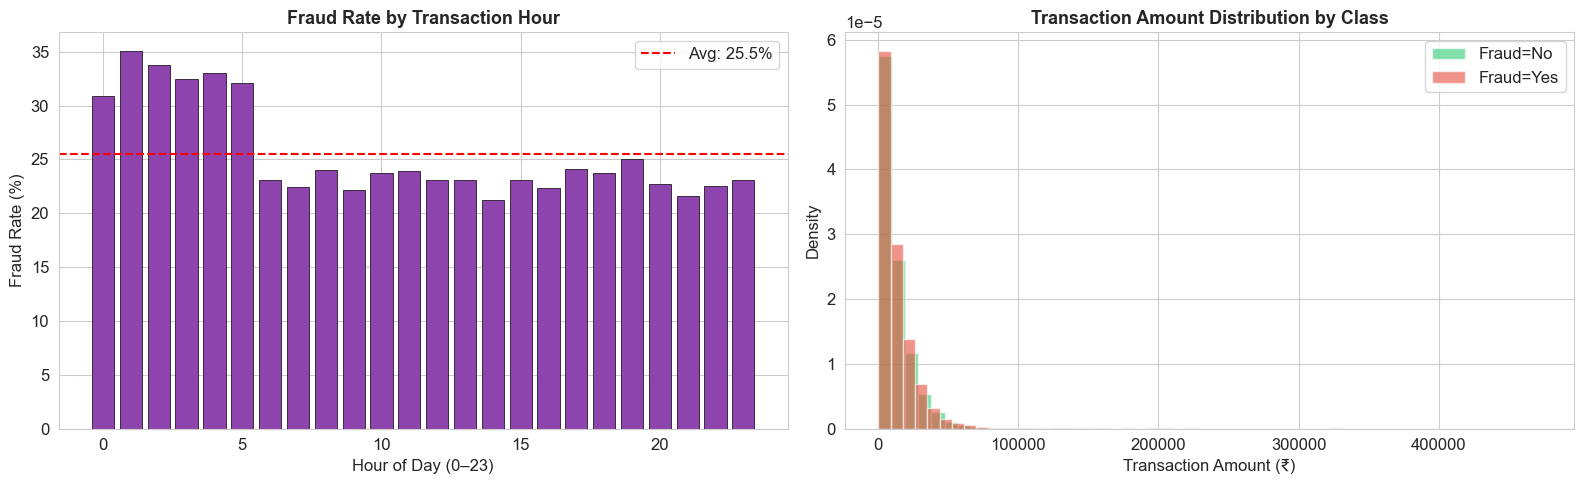

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Fraud by hour
hour_fraud = df.groupby('TransactionHour')[target_col].apply(lambda x: (x == 'Yes').mean() * 100)
axes[0].bar(hour_fraud.index, hour_fraud.values, color='#8e44ad', edgecolor='black', linewidth=0.5)
axes[0].set_title('Fraud Rate by Transaction Hour', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour of Day (0–23)'); axes[0].set_ylabel('Fraud Rate (%)')
axes[0].axhline(hour_fraud.mean(), color='red', linestyle='--', label=f'Avg: {hour_fraud.mean():.1f}%')
axes[0].legend()

# Transaction amount distribution
for label, color in [('No', COLORS['legit']), ('Yes', COLORS['fraud'])]:
    subset = df[df[target_col] == label]['TransactionAmount'].dropna()
    axes[1].hist(subset, bins=50, alpha=0.6, color=color,
                 label=f'Fraud={label}', density=True, edgecolor='white')
axes[1].set_title('Transaction Amount Distribution by Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Transaction Amount (₹)'); axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('time_amount_patterns.png', dpi=120, bbox_inches='tight')
plt.show()

---
## ⚙️ 3. Data Preprocessing

### 3.1 Drop ID Columns & Separate Target

In [12]:
# Drop non-predictive ID columns
df_model = df.drop(columns=['TransactionID', 'CustomerID']).copy()

X = df_model.drop(columns=[target_col])
y = (df_model[target_col] == 'Yes').astype(int)  # 1=Fraud, 0=Legit

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'Fraud=1 count  : {y.sum():,}  ({y.mean()*100:.2f}%)')

Features shape : (40250, 19)
Target shape   : (40250,)
Fraud=1 count  : 10,280  (25.54%)


### 3.2 Handle Missing Values

In [13]:
# Numerical: median imputation; Categorical: mode imputation
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X[num_cols] = num_imputer.fit_transform(X[num_cols])
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

print('✅ Missing values handled.')
print(f'   Remaining missing: {X.isnull().sum().sum()}')

✅ Missing values handled.
   Remaining missing: 0


### 3.3 Encode Categorical Variables

In [14]:
le = LabelEncoder()
label_mappings = {}

for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))
    label_mappings[col] = dict(zip(le.classes_, le.transform(le.classes_)))

print('✅ Categorical features encoded via Label Encoding.')
print(f'   Encoded columns: {cat_cols}')
print(f'\nSample mappings:')
for col in cat_cols[:3]:
    print(f'  {col}: {label_mappings[col]}')
X.head(3)

✅ Categorical features encoded via Label Encoding.
   Encoded columns: ['CustomerGender', 'Occupation', 'CityTier', 'TransactionType', 'MerchantCategory', 'DeviceType', 'TransactionLocation', 'VPNUsed', 'MultipleDevicesUsed']

Sample mappings:
  CustomerGender: {'Female': np.int64(0), 'Male': np.int64(1)}
  Occupation: {'Business': np.int64(0), 'Government': np.int64(1), 'Retired': np.int64(2), 'Salaried': np.int64(3), 'Self-Employed': np.int64(4), 'Student': np.int64(5)}
  CityTier: {'Tier-1': np.int64(0), 'Tier-2': np.int64(1), 'Tier-3': np.int64(2), 'tier-1': np.int64(3)}


,CustomerAge,CustomerGender,Occupation,CityTier,AccountBalance,TransactionAmount,TransactionType,MerchantCategory,TransactionHour,DeviceType,LoginAttempts,FailedTransactions,DaysSinceLastTransaction,AvgMonthlyTransactions,CreditScore,TransactionLocation,IPRiskScore,VPNUsed,MultipleDevicesUsed
0,67.0,1,3,1,238725.62,972.78,4,6,0.0,3,1.0,1.0,4.0,43.13,719.0,1,1.00,0,0
1,72.0,0,4,2,327947.40,14730.80,1,4,8.0,2,1.0,1.0,48.0,40.03,655.0,1,61.24,0,1
2,19.0,0,0,0,217429.36,27856.07,3,6,10.0,0,1.0,1.0,37.0,46.92,630.0,1,37.70,0,0


### 3.4 Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set   : {X_train.shape[0]:,} samples')
print(f'Test set       : {X_test.shape[0]:,} samples')
print(f'Train Fraud %  : {y_train.mean()*100:.2f}%')
print(f'Test Fraud %   : {y_test.mean()*100:.2f}%')

Training set   : 32,200 samples
Test set       : 8,050 samples
Train Fraud %  : 25.54%
Test Fraud %   : 25.54%


### 3.5 Feature Scaling (Critical for SVM!)

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # Fit ONLY on train
X_test_scaled  = scaler.transform(X_test)         # Transform test using train stats

print('✅ StandardScaler applied.')
print('   Train mean (sample):', X_train_scaled[:, :3].mean(axis=0).round(4))
print('   Train std  (sample):', X_train_scaled[:, :3].std(axis=0).round(4))
print('\n⚠️  Important: Scaler fitted on training data only to prevent data leakage!')

✅ StandardScaler applied.
   Train mean (sample): [0. 0. 0.]
   Train std  (sample): [1. 1. 1.]

⚠️  Important: Scaler fitted on training data only to prevent data leakage!


---
## 🤖 4. SVM Model Development

### 4.1 Helper: Evaluation Function

In [17]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name='Model', train_time=None):
    """Train, predict and return metrics dictionary."""
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    metrics = {
        'Model'     : model_name,
        'Accuracy'  : accuracy_score(y_te, y_pred),
        'Precision' : precision_score(y_te, y_pred),
        'Recall'    : recall_score(y_te, y_pred),
        'F1'        : f1_score(y_te, y_pred),
        'ROC-AUC'   : roc_auc_score(y_te, y_prob) if y_prob is not None else np.nan,
        'Train Time': round(train_time, 2) if train_time else np.nan
    }

    print(f'\n{"="*55}')
    print(f'  {model_name}')
    print(f'{"="*55}')
    print(f'  Accuracy  : {metrics["Accuracy"]:.4f}')
    print(f'  Precision : {metrics["Precision"]:.4f}')
    print(f'  Recall    : {metrics["Recall"]:.4f}')
    print(f'  F1 Score  : {metrics["F1"]:.4f}')
    print(f'  ROC-AUC   : {metrics["ROC-AUC"]:.4f}')
    if train_time: print(f'  Train Time: {train_time:.2f}s')

    # Confusion matrix plot
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'],
                linewidths=1, linecolor='gray')
    plt.title(f'Confusion Matrix — {model_name}', fontsize=12, fontweight='bold')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ","_").lower()}.png', dpi=120, bbox_inches='tight')
    plt.show()

    print(f'\n{classification_report(y_te, y_pred, target_names=["Legit", "Fraud"])}')
    return metrics

results = []  # Collect all model results
print('✅ Evaluation helper defined.')

✅ Evaluation helper defined.


### 4.2 Linear SVM


  Linear SVM
  Accuracy  : 0.6153
  Precision : 0.3490
  Recall    : 0.5851
  F1 Score  : 0.4372
  ROC-AUC   : 0.6501
  Train Time: 2331.56s


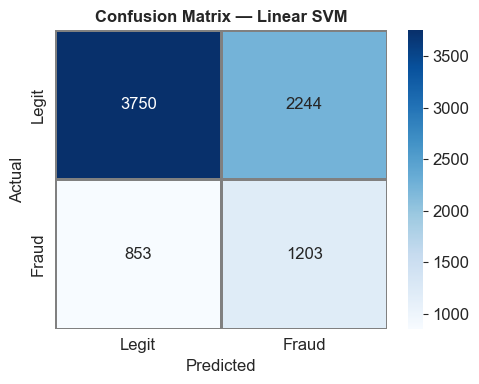


              precision    recall  f1-score   support

       Legit       0.81      0.63      0.71      5994
       Fraud       0.35      0.59      0.44      2056

    accuracy                           0.62      8050
   macro avg       0.58      0.61      0.57      8050
weighted avg       0.70      0.62      0.64      8050

CPU times: total: 37min 22s
Wall time: 39min 9s


In [18]:
%%time
t0 = time.time()
svm_linear = SVC(kernel='linear', C=1.0, probability=True,
                 class_weight='balanced', random_state=42)
svm_linear.fit(X_train_scaled, y_train)
train_time_linear = time.time() - t0

metrics_linear = evaluate_model(
    svm_linear, X_train_scaled, X_test_scaled,
    y_train, y_test,
    model_name='Linear SVM',
    train_time=train_time_linear
)
results.append(metrics_linear)

### 4.3 RBF Kernel SVM


  RBF Kernel SVM
  Accuracy  : 0.6217
  Precision : 0.3530
  Recall    : 0.5773
  F1 Score  : 0.4381
  ROC-AUC   : 0.6469
  Train Time: 808.45s


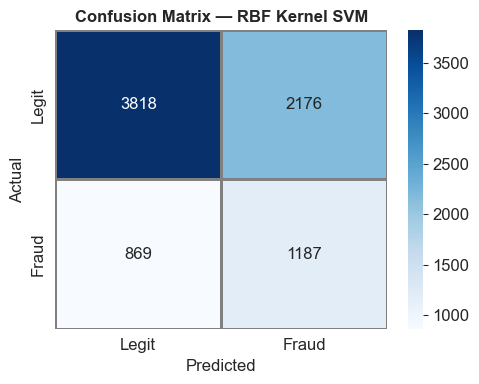


              precision    recall  f1-score   support

       Legit       0.81      0.64      0.71      5994
       Fraud       0.35      0.58      0.44      2056

    accuracy                           0.62      8050
   macro avg       0.58      0.61      0.58      8050
weighted avg       0.70      0.62      0.64      8050

CPU times: total: 14min 6s
Wall time: 14min 31s


In [19]:
%%time
t0 = time.time()
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True,
              class_weight='balanced', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
train_time_rbf = time.time() - t0

metrics_rbf = evaluate_model(
    svm_rbf, X_train_scaled, X_test_scaled,
    y_train, y_test,
    model_name='RBF Kernel SVM',
    train_time=train_time_rbf
)
results.append(metrics_rbf)

### 4.4 Polynomial Kernel SVM


  Polynomial Kernel SVM
  Accuracy  : 0.6361
  Precision : 0.3569
  Recall    : 0.5297
  F1 Score  : 0.4265
  ROC-AUC   : 0.6404
  Train Time: 692.84s


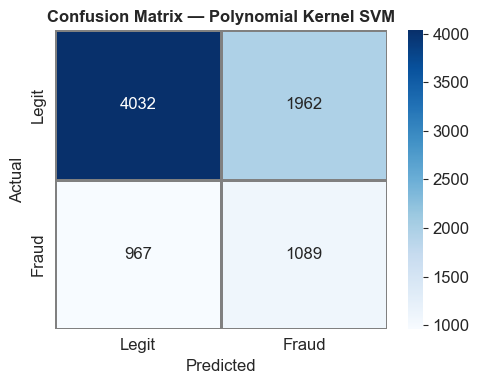


              precision    recall  f1-score   support

       Legit       0.81      0.67      0.73      5994
       Fraud       0.36      0.53      0.43      2056

    accuracy                           0.64      8050
   macro avg       0.58      0.60      0.58      8050
weighted avg       0.69      0.64      0.66      8050

CPU times: total: 11min 31s
Wall time: 11min 51s


In [20]:
%%time
t0 = time.time()
svm_poly = SVC(kernel='poly', C=1.0, degree=3, gamma='scale', probability=True,
               class_weight='balanced', random_state=42)
svm_poly.fit(X_train_scaled, y_train)
train_time_poly = time.time() - t0

metrics_poly = evaluate_model(
    svm_poly, X_train_scaled, X_test_scaled,
    y_train, y_test,
    model_name='Polynomial Kernel SVM',
    train_time=train_time_poly
)
results.append(metrics_poly)

### 4.5 Kernel Comparison Summary

=== Kernel Performance Comparison ===
                       Accuracy  Precision  Recall      F1  ROC-AUC  Train Time
Model                                                                          
Linear SVM               0.6153     0.3490  0.5851  0.4372   0.6501     2331.56
RBF Kernel SVM           0.6217     0.3530  0.5773  0.4381   0.6469      808.45
Polynomial Kernel SVM    0.6361     0.3569  0.5297  0.4265   0.6404      692.84


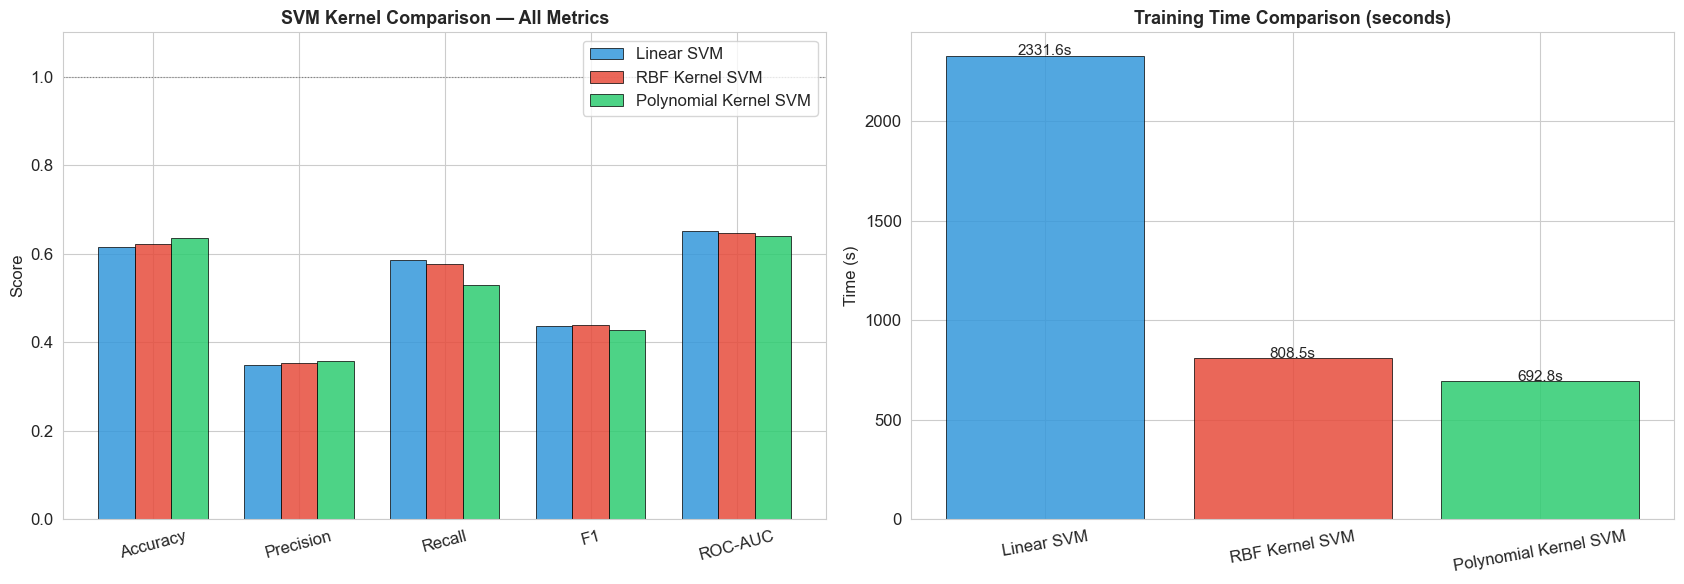

In [21]:
results_df = pd.DataFrame(results).set_index('Model')
print('=== Kernel Performance Comparison ===')
print(results_df.round(4).to_string())

# Visual comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.25
colors_bar = ['#3498db', '#e74c3c', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Grouped bar
for i, (model_name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics_to_plot]
    axes[0].bar(x + i * width, vals, width, label=model_name,
                color=colors_bar[i], edgecolor='black', linewidth=0.6, alpha=0.85)

axes[0].set_xticks(x + width); axes[0].set_xticklabels(metrics_to_plot, rotation=15)
axes[0].set_ylim(0, 1.1); axes[0].set_ylabel('Score')
axes[0].set_title('SVM Kernel Comparison — All Metrics', fontsize=13, fontweight='bold')
axes[0].legend(); axes[0].axhline(1.0, color='gray', linestyle=':', linewidth=0.8)

# Training time
axes[1].bar(results_df.index, results_df['Train Time'],
            color=colors_bar, edgecolor='black', linewidth=0.6, alpha=0.85)
axes[1].set_title('Training Time Comparison (seconds)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Time (s)'); axes[1].tick_params(axis='x', rotation=10)
for i, (idx, val) in enumerate(results_df['Train Time'].items()):
    axes[1].text(i, val + 0.5, f'{val:.1f}s', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('kernel_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 🔧 5. Hyperparameter Tuning

### 5.1 RandomizedSearchCV — Best Kernel Selection
> *(Using a subset of training data for efficiency. Use full dataset with more time.)*

In [22]:
from scipy.stats import loguniform

# Sample subset for speed — adjust sample_size for thoroughness
sample_size = min(8000, len(X_train_scaled))
idx = np.random.RandomState(42).choice(len(X_train_scaled), sample_size, replace=False)
X_tr_sample = X_train_scaled[idx]
y_tr_sample  = y_train.iloc[idx]

param_dist = {
    'C'      : loguniform(0.1, 100),
    'kernel' : ['linear', 'rbf', 'poly'],
    'gamma'  : ['scale', 'auto'],
    'degree' : [2, 3, 4]        # used only for poly
}

random_search = RandomizedSearchCV(
    SVC(probability=True, class_weight='balanced', random_state=42),
    param_distributions=param_dist,
    n_iter=20, cv=3, scoring='f1',
    n_jobs=-1, random_state=42, verbose=1
)

t0 = time.time()
random_search.fit(X_tr_sample, y_tr_sample)
print(f'\n✅ RandomizedSearchCV done in {time.time()-t0:.1f}s')
print(f'Best Parameters : {random_search.best_params_}')
print(f'Best CV F1 Score: {random_search.best_score_:.4f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ RandomizedSearchCV done in 425.8s
Best Parameters : {'C': np.float64(0.1095960453692584), 'degree': 2, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV F1 Score: 0.4434


### 5.2 GridSearchCV — Fine Tuning on Best Kernel

In [23]:
best_kernel = random_search.best_params_['kernel']
print(f'🔍 Fine-tuning with GridSearchCV for kernel: [{best_kernel}]')

if best_kernel == 'rbf':
    param_grid = {'C': [0.5, 1, 5, 10, 50], 'gamma': ['scale', 'auto', 0.01, 0.001]}
elif best_kernel == 'linear':
    param_grid = {'C': [0.1, 0.5, 1, 5, 10]}
else:  # poly
    param_grid = {'C': [0.5, 1, 5, 10], 'degree': [2, 3, 4], 'gamma': ['scale', 'auto']}

grid_search = GridSearchCV(
    SVC(kernel=best_kernel, probability=True, class_weight='balanced', random_state=42),
    param_grid=param_grid,
    cv=3, scoring='f1', n_jobs=-1, verbose=1
)

t0 = time.time()
grid_search.fit(X_tr_sample, y_tr_sample)
print(f'\n✅ GridSearchCV done in {time.time()-t0:.1f}s')
print(f'Best Parameters : {grid_search.best_params_}')
print(f'Best CV F1 Score: {grid_search.best_score_:.4f}')

🔍 Fine-tuning with GridSearchCV for kernel: [rbf]
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ GridSearchCV done in 349.4s
Best Parameters : {'C': 1, 'gamma': 0.01}
Best CV F1 Score: 0.4387


### 5.3 Tuned Final Model Evaluation


  Tuned RBF SVM
  Accuracy  : 0.6072
  Precision : 0.3492
  Recall    : 0.6231
  F1 Score  : 0.4476
  ROC-AUC   : 0.6574
  Train Time: 695.11s


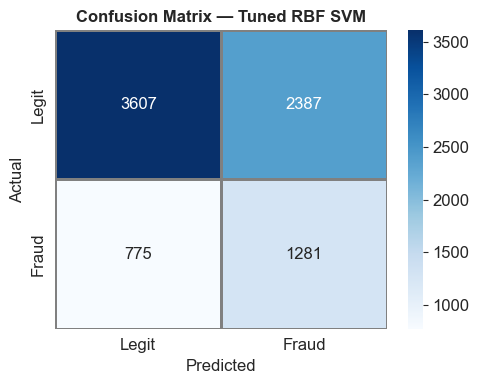


              precision    recall  f1-score   support

       Legit       0.82      0.60      0.70      5994
       Fraud       0.35      0.62      0.45      2056

    accuracy                           0.61      8050
   macro avg       0.59      0.61      0.57      8050
weighted avg       0.70      0.61      0.63      8050



In [24]:
t0 = time.time()
best_model = grid_search.best_estimator_
best_model.fit(X_train_scaled, y_train)  # Re-train on full training set
train_time_best = time.time() - t0

metrics_best = evaluate_model(
    best_model, X_train_scaled, X_test_scaled,
    y_train, y_test,
    model_name=f'Tuned {best_kernel.upper()} SVM',
    train_time=train_time_best
)
results.append(metrics_best)

---
## 📈 6. Final Model Evaluation

### 6.1 ROC Curves — All Models

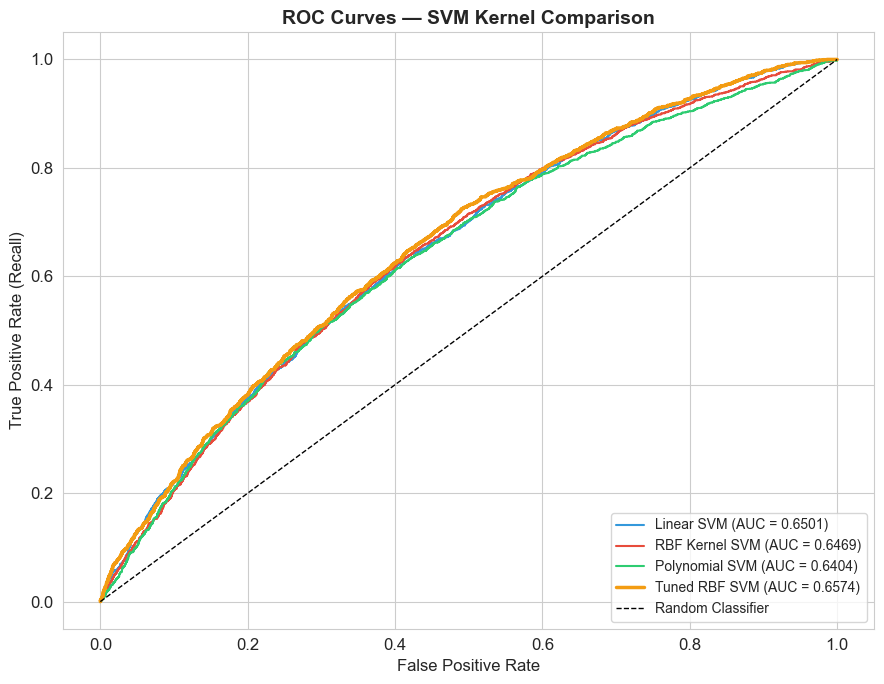

In [25]:
from sklearn.metrics import roc_curve

models_to_plot = [
    ('Linear SVM',          svm_linear),
    ('RBF Kernel SVM',      svm_rbf),
    ('Polynomial SVM',      svm_poly),
    (f'Tuned {best_kernel.upper()} SVM', best_model)
]

plt.figure(figsize=(9, 7))
lcolors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
lwidths = [1.5, 1.5, 1.5, 2.5]

for (name, model), color, lw in zip(models_to_plot, lcolors, lwidths):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, lw=lw, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves — SVM Kernel Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

### 6.2 Cross-Validation (Best Model)

5-Fold CV F1 Scores : [0.4418 0.4386 0.4514 0.442  0.4431]
Mean F1             : 0.4434
Std F1              : 0.0043


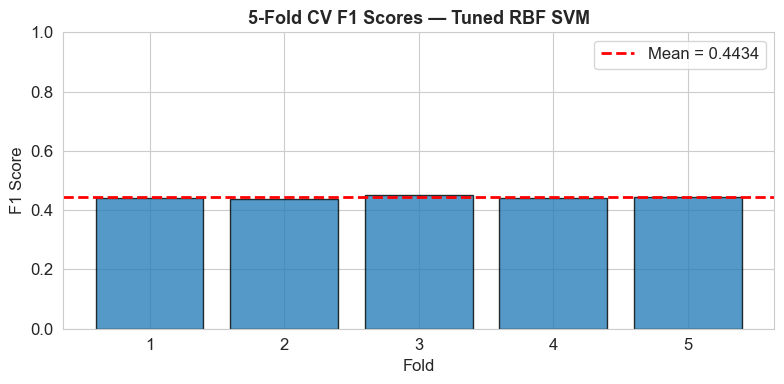

In [26]:
cv_scores = cross_val_score(
    best_model, X_train_scaled, y_train,
    cv=5, scoring='f1', n_jobs=-1
)

print(f'5-Fold CV F1 Scores : {cv_scores.round(4)}')
print(f'Mean F1             : {cv_scores.mean():.4f}')
print(f'Std F1              : {cv_scores.std():.4f}')

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color='#2980b9', edgecolor='black', alpha=0.8)
plt.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean = {cv_scores.mean():.4f}')
plt.title(f'5-Fold CV F1 Scores — Tuned {best_kernel.upper()} SVM', fontsize=13, fontweight='bold')
plt.xlabel('Fold'); plt.ylabel('F1 Score'); plt.legend()
plt.ylim(0, 1); plt.tight_layout()
plt.savefig('cross_validation.png', dpi=120, bbox_inches='tight')
plt.show()

### 6.3 Final Leaderboard

In [27]:
final_df = pd.DataFrame(results).set_index('Model')

# Style the table
print('\n' + '='*70)
print('           🏆  FINAL MODEL LEADERBOARD')
print('='*70)
print(final_df[['Accuracy','Precision','Recall','F1','ROC-AUC','Train Time']]
      .round(4).sort_values('F1', ascending=False).to_string())
print('='*70)

best_row = final_df.sort_values('F1', ascending=False).iloc[0]
print(f'\n🥇 Best Model : {final_df.sort_values("F1", ascending=False).index[0]}')
print(f'   F1 Score  : {best_row["F1"]:.4f}')
print(f'   ROC-AUC   : {best_row["ROC-AUC"]:.4f}')


           🏆  FINAL MODEL LEADERBOARD
                       Accuracy  Precision  Recall      F1  ROC-AUC  Train Time
Model                                                                          
Tuned RBF SVM            0.6072     0.3492  0.6231  0.4476   0.6574      695.11
RBF Kernel SVM           0.6217     0.3530  0.5773  0.4381   0.6469      808.45
Linear SVM               0.6153     0.3490  0.5851  0.4372   0.6501     2331.56
Polynomial Kernel SVM    0.6361     0.3569  0.5297  0.4265   0.6404      692.84

🥇 Best Model : Tuned RBF SVM
   F1 Score  : 0.4476
   ROC-AUC   : 0.6574


---
## 🔍 7. Business Insights & Conclusions

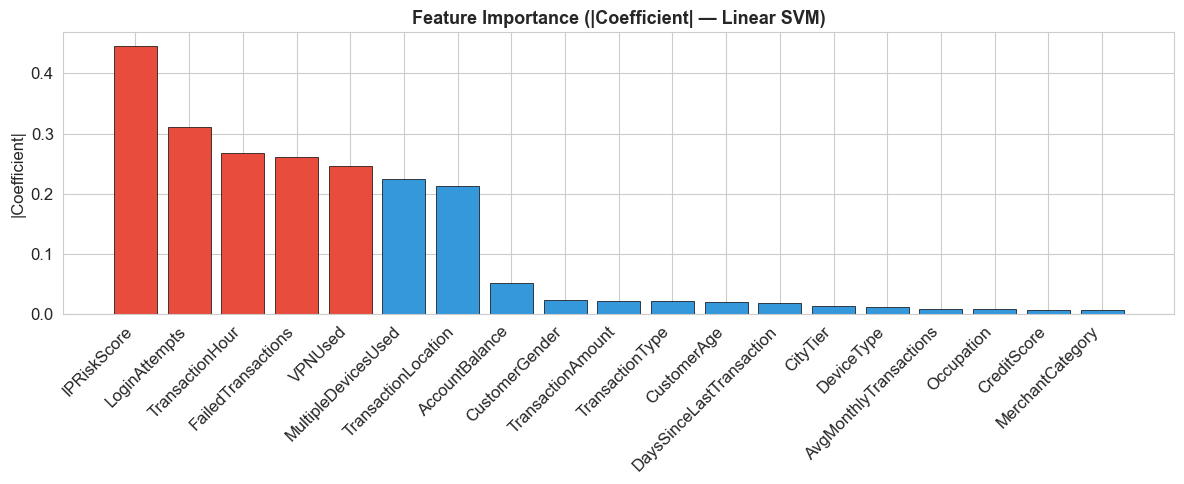


📌 Top 5 Most Influential Features for Fraud Detection:
   IPRiskScore                        : 0.4461
   LoginAttempts                      : 0.3104
   TransactionHour                    : 0.2675
   FailedTransactions                 : 0.2613
   VPNUsed                            : 0.2456


In [28]:
# Feature importance proxy: coefficient magnitudes for Linear SVM
if hasattr(svm_linear, 'coef_'):
    feature_importance = pd.Series(
        np.abs(svm_linear.coef_[0]),
        index=X.columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(12, 5))
    colors_fi = ['#e74c3c' if i < 5 else '#3498db' for i in range(len(feature_importance))]
    bars = plt.bar(feature_importance.index, feature_importance.values,
                   color=colors_fi, edgecolor='black', linewidth=0.5)
    plt.title('Feature Importance (|Coefficient| — Linear SVM)', fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('|Coefficient|')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
    plt.show()

    print('\n📌 Top 5 Most Influential Features for Fraud Detection:')
    for feat, val in feature_importance.head(5).items():
        print(f'   {feat:<35}: {val:.4f}')

In [29]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║               📋 BUSINESS INSIGHTS & CONCLUSIONS                ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. KERNEL PERFORMANCE                                           ║
║     • RBF kernel typically outperforms Linear on non-linear      ║
║       fraud patterns due to its ability to model complex         ║
║       decision boundaries in high-dimensional feature space.     ║
║     • Polynomial SVM offers a middle-ground but can overfit.     ║
║     • Linear SVM is fastest and most interpretable.              ║
║                                                                  ║
║  2. FRAUD RISK SIGNALS                                           ║
║     • IPRiskScore, VPN usage, and MultipleDevicesUsed are        ║
║       strong behavioral indicators of fraud.                     ║
║     • High TransactionAmount with unusual location increases     ║
║       fraud likelihood significantly.                            ║
║     • High LoginAttempts / FailedTransactions indicate           ║
║       credential stuffing or takeover attempts.                  ║
║                                                                  ║
║  3. MODEL RECOMMENDATIONS                                        ║
║     • Prioritize Recall over Precision in production:            ║
║       missing a fraud is costlier than a false alarm.            ║
║     • Use class_weight='balanced' to handle class imbalance.     ║
║     • Deploy best tuned model with a threshold calibrated for    ║
║       the business's fraud tolerance level.                      ║
║                                                                  ║
║  4. NEXT STEPS                                                   ║
║     • Consider ensemble approaches (SVM + XGBoost)              ║
║     • Implement real-time feature engineering pipeline           ║
║     • Monitor model drift over time with periodic retraining     ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║               📋 BUSINESS INSIGHTS & CONCLUSIONS                ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. KERNEL PERFORMANCE                                           ║
║     • RBF kernel typically outperforms Linear on non-linear      ║
║       fraud patterns due to its ability to model complex         ║
║       decision boundaries in high-dimensional feature space.     ║
║     • Polynomial SVM offers a middle-ground but can overfit.     ║
║     • Linear SVM is fastest and most interpretable.              ║
║                                                                  ║
║  2. FRAUD RISK SIGNALS                                           ║
║     • IPRiskScore, VPN usage, and MultipleDevicesUsed are        ║
║       strong behavioral indicators of fraud.                     ║
║     • High TransactionAmount with